<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Supervised Learning - Decision Tree - Titanic
</b></font> </br></p>

---


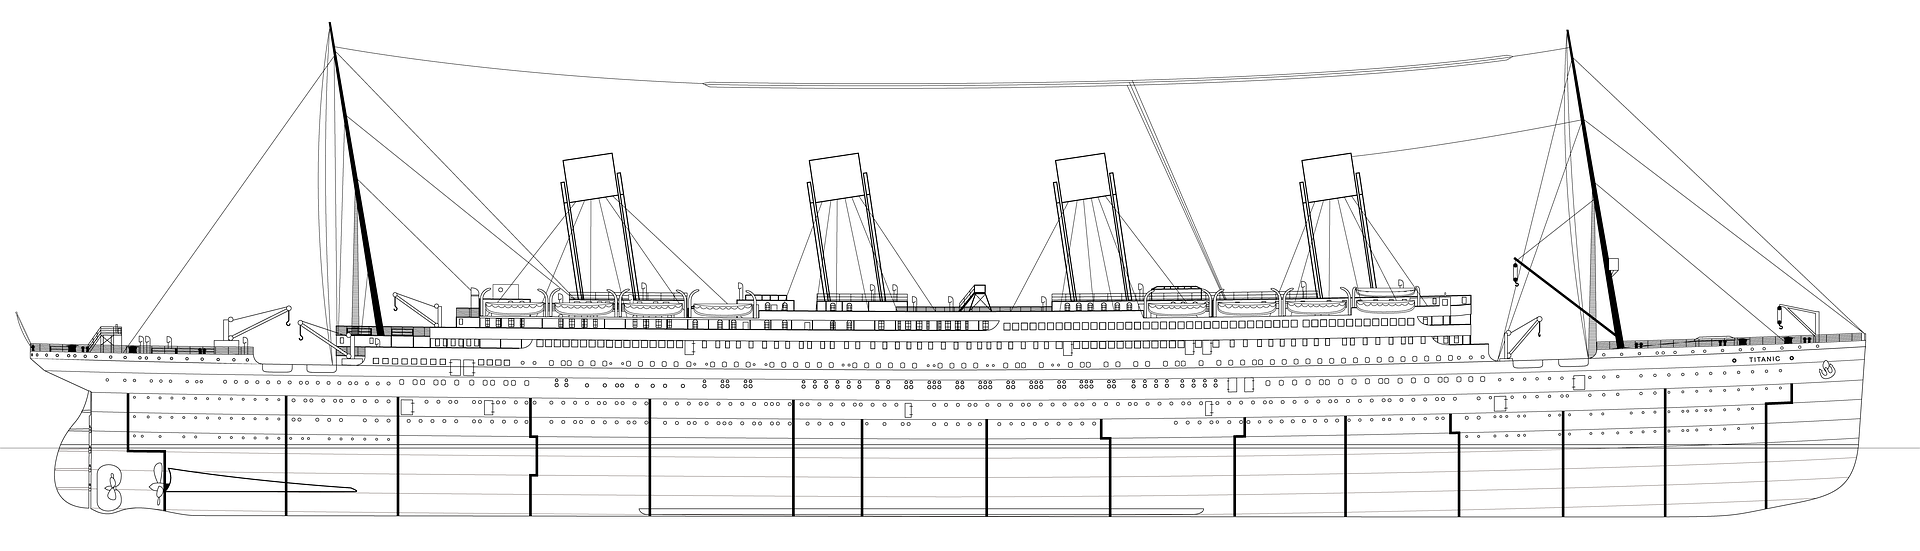

Bild von <a href="https://pixabay.com/de/users/axonia-14892766/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">axonia</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">Pixabay</a>

# **0  <font color='orange'>|</font> Install & Import**
***

In [ ]:
# Install
!pip install -q dtreeviz

In [ ]:
# Import
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import tree
from sklearn.tree import export_text

import plotly.express as px
import plotly.subplots as sp

import graphviz
import dtreeviz

from yellowbrick.model_selection import validation_curve
from yellowbrick.model_selection import learning_curve

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')

# **1  <font color='orange'>|</font> Understand**
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Dies ist der legendäre Titanic ML-Wettbewerb – die beste erste Herausforderung, um in ML-Modellierung einzutauchen.

Die Aufgabe ist einfach: Verwenden Sie maschinelles Lernen, um ein Modell zu erstellen, das vorhersagt, welche Passagiere den Schiffbruch der Titanic überlebt haben.

[Titanic Org](https://www.encyclopedia-titanica.org/)

[DataSet](https://www.openml.org/search?type=data&status=active&id=41265)

[Info](https://www.kaggle.com/competitions/titanic/data)



**Datenfelder:**   
+ Age: Alter
+ Fare: Ticketpreis
+ Sex: Geschlecht (0 = männlich, 1 = weiblich)
+ sibsp: Der Datensatz definiert Familienbeziehungen auf diese Weise ... Geschwister = Bruder, Schwester, Stiefbruder, Stiefschwester Ehepartner = Ehemann, Ehefrau (Geliebte und Verlobte wurden ignoriert)
+ parch: Der Datensatz definiert Familienbeziehungen auf diese Weise ... Elternteil = Mutter, Vater Kind = Tochter, Sohn, Stieftochter, Stiefsohn. Einige Kinder reisten nur mit einem Kindermädchen, daher ist für sie Parch=0
+ Pclass: Passagierklasse, 1.- 3. Klasse
+ Embarked: Hafen der Einschiffung

In [ ]:
df = fetch_openml(parser='auto', target_column='X2urvived', data_id=41265)
data = df.data.copy()
target = df.target.copy()

<p><font color='black' size="5">
🔎 EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1307 entries, 0 to 1306
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1307 non-null   float64
 1   Fare      1307 non-null   float64
 2   Sex       1307 non-null   int64  
 3   sibsp     1307 non-null   int64  
 4   Parch     1307 non-null   int64  
 5   Pclass    1307 non-null   int64  
 6   Embarked  1307 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 71.6 KB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1307.0,29.471821,12.881592,0.17,22.0000,28.0000,35.000,80.0000
Fare,1307.0,33.209595,51.748768,0.00,7.8958,14.4542,31.275,512.3292
Sex,1307.0,0.355011,0.478700,0.00,0.0000,0.0000,1.000,1.0000
sibsp,1307.0,0.499617,1.042273,0.00,0.0000,0.0000,1.000,8.0000
Parch,1307.0,0.385616,0.866092,0.00,0.0000,0.0000,0.000,9.0000
Pclass,1307.0,2.296863,0.836942,1.00,2.0000,3.0000,3.000,3.0000
Embarked,1307.0,1.492731,0.814626,0.00,1.0000,2.0000,2.000,2.0000


In [ ]:
data.groupby('Sex').count()

,Age,Fare,sibsp,Parch,Pclass,Embarked
Sex,,,,,,
0,843,843,843,843,843,843
1,464,464,464,464,464,464


In [ ]:
target.value_counts()

X2urvived
0    967
1    340
Name: count, dtype: int64

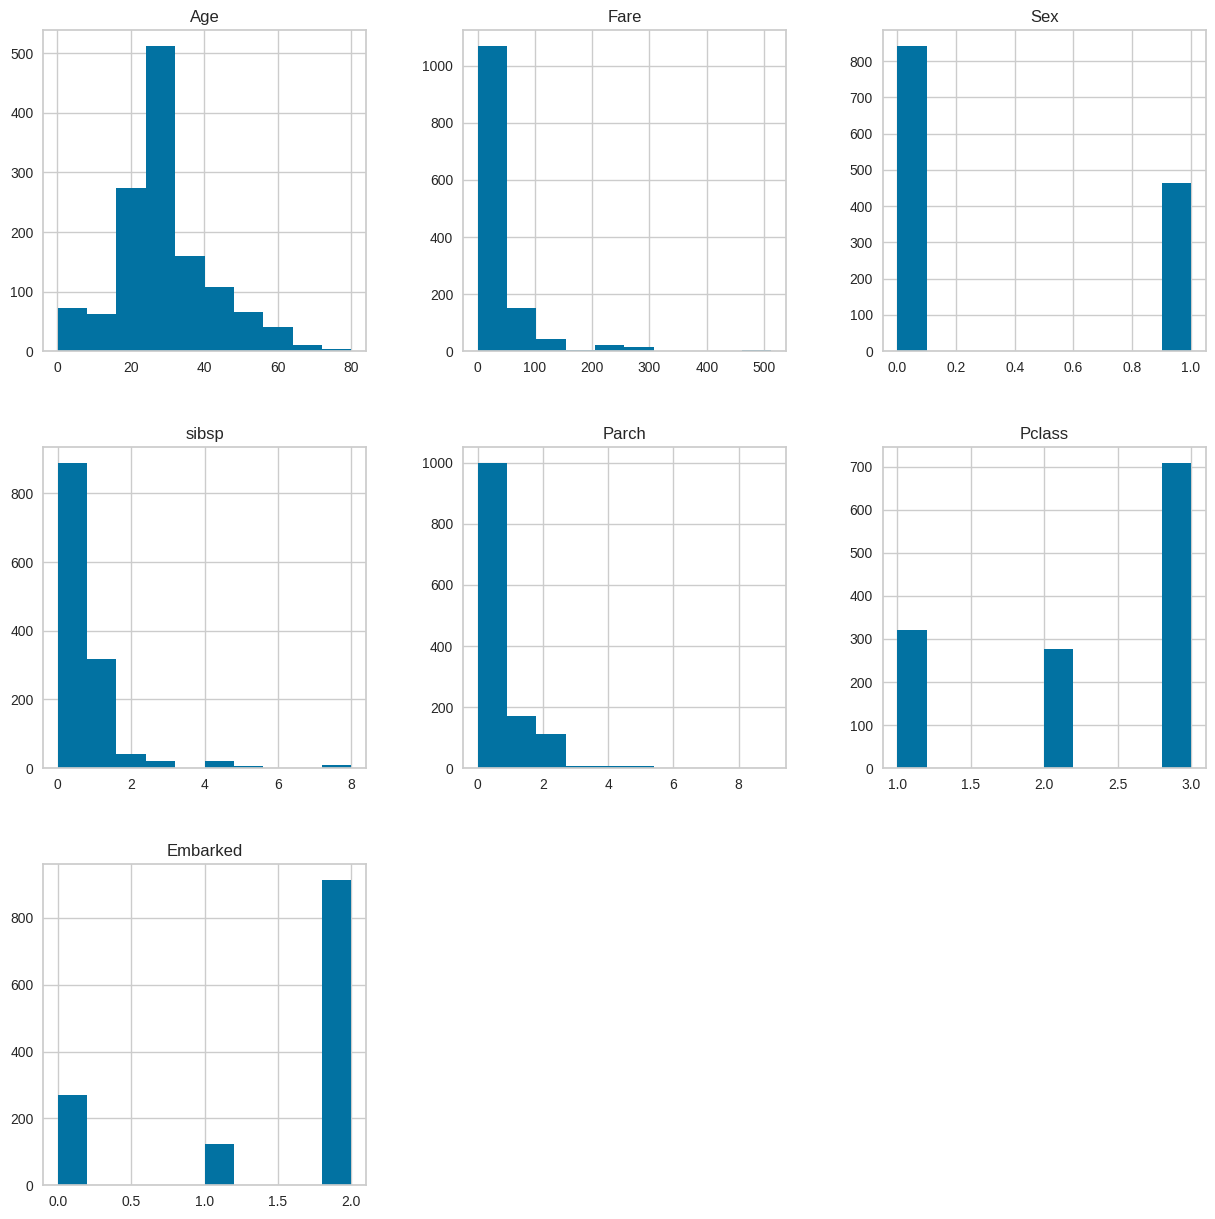

In [ ]:
_ = data.hist(figsize=(15,15))

# **2 <font color='orange'>|</font> Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features codieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
✂️ Train-Test-Split
</font></p>


In [ ]:
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.20, random_state=42, stratify=target)

In [ ]:
data_train.shape, data_test.shape, target_train.shape, target_test.shape

((1045, 7), (262, 7), (1045,), (262,))

# **3 <font color='orange'>|</font> Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Valdiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
🏃 Modellauswahl & Training
</font></p>

In [ ]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
model.fit(data_train, target_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

# **4 <font color='orange'>|</font> Evaluate**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
🔭 Prognose
</font></p>

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

<p><font color='black' size="5">
🎯 Accuracy
</font></p>

In [ ]:
acc_train = accuracy_score(target_train, target_train_pred) * 100
print (f"Modell: {model} -- Train -- Accuracy: {acc_train:5.1f}%")

Modell: DecisionTreeClassifier(max_depth=3, random_state=42) -- Train -- Accuracy:  81.1%


In [ ]:
acc_test = accuracy_score(target_test, target_test_pred) * 100
print (f'Modell: {model} -- Test -- Accuracy: {acc_test:5.1f}%')

Modell: DecisionTreeClassifier(max_depth=3, random_state=42) -- Test -- Accuracy:  75.6%


<p><font color='black' size="5">
📱 Confusion Matrix
</font></p>

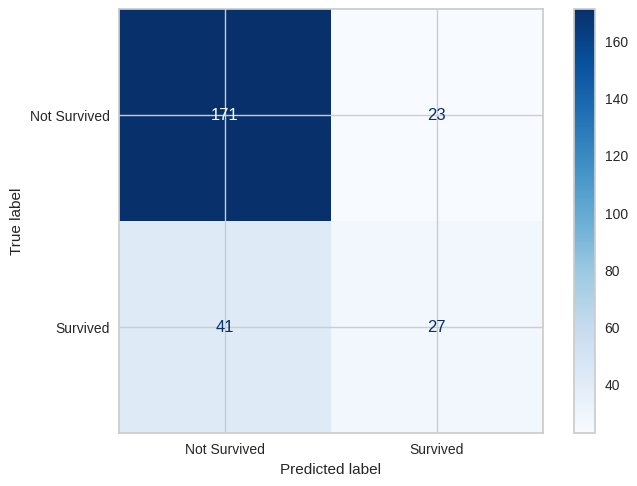

In [ ]:
conf_matrix = confusion_matrix(target_test, target_test_pred)
display_labels_= ['Not Survived','Survived']
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels_)
disp.plot(cmap='Blues')

In [ ]:
print(classification_report(target_test, target_test_pred, target_names=display_labels_))

              precision    recall  f1-score   support

Not Survived       0.81      0.88      0.84       194
    Survived       0.54      0.40      0.46        68

    accuracy                           0.76       262
   macro avg       0.67      0.64      0.65       262
weighted avg       0.74      0.76      0.74       262



<p><font color='black' size="5">
🎲Aufbau Analysewürfel
</font></p>

In [ ]:
# Übernahme der Testdaten
cube = data_test.copy()
cube.reset_index(inplace=True)

In [ ]:
# Übernahme Target real & predict
cube['real'] = pd.DataFrame(target_test.values, columns=['real'])
cube['predict'] = pd.DataFrame(target_test_pred, columns=['predict'])

<p><font color='black' size="5">
📊 Visualisierung real vs predict
</font></p>

In [ ]:
# Histogramm
title_ = 'Histogramm real vs predict'
fig = px.histogram(cube, x=['real', 'predict'], nbins=2, title=title_)
fig.update_layout(barmode='group',bargap=0.1, width=600, height=600)
fig.show()

<p><font color='black' size="5">
📛 Fehlerhafte Vorhersagen
</font></p>

In [ ]:
# real <> predict
cube[cube.real != cube.predict].describe().T

,count,mean,std,min,25%,50%,75%,max
index,64.0,609.531250,389.447308,7.00,281.25,633.00,937.50,1303.0000
Age,64.0,28.059844,12.474087,0.83,22.75,28.00,33.50,60.0000
Fare,64.0,46.786005,75.778995,0.00,8.05,21.55,43.50,512.3292
Sex,64.0,0.625000,0.487950,0.00,0.00,1.00,1.00,1.0000
sibsp,64.0,0.375000,0.678467,0.00,0.00,0.00,1.00,3.0000
Parch,64.0,0.421875,0.905095,0.00,0.00,0.00,0.25,5.0000
Pclass,64.0,2.109375,0.875000,1.00,1.00,2.00,3.00,3.0000
Embarked,64.0,1.296875,0.902900,0.00,0.00,2.00,2.00,2.0000
real,64.0,0.640625,0.483610,0.00,0.00,1.00,1.00,1.0000
predict,64.0,0.359375,0.483610,0.00,0.00,0.00,1.00,1.0000


In [ ]:
cube[cube.real != cube.predict]

,index,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,real,predict
2,1073,27.0,247.5208,1,1,1,1,0,0,1
8,572,28.0,7.7500,1,0,0,3,1,1,0
12,186,45.0,26.5500,0,0,0,1,2,1,0
15,52,49.0,76.7292,1,1,0,1,0,1,0
16,1067,36.0,39.0000,1,0,3,2,2,0,1
...,...,...,...,...,...,...,...,...,...,...
247,25,38.0,31.3875,1,1,5,3,2,1,0
248,127,28.0,22.3583,1,1,1,3,0,1,0
249,873,15.0,7.2250,1,0,0,3,0,1,0
255,901,23.0,82.2667,1,1,0,1,2,0,1


<p><font color='black' size="5">
📝 Einzelne Vorhersage
</font></p>

In [ ]:
# 2 neue Datensätze werden zur Prognose an das Modell übergeben: Rose & Jack (diCaprio/Winslet)
new_data = { 'Age': [22, 23], 'Fare': [200, 0], 'Sex': [1, 0], 'sibsp': [0, 0], 'Parch': [0, 0], 'Pclass': [1, 3],'Embarked': [0,0] }
new = pd.DataFrame(new_data)

In [ ]:
# Vorhersage erstellen Rose & Jack
model.predict(new)

array([1, 0])

<p><font color='black' size="5">
❗Feature Importance
</font></p>

In [ ]:
title_ = 'Feature Importance Titanic'
px.bar(x=model.feature_importances_, y=data.columns, title = title_, width=800, height=600).update_yaxes(categoryorder="total ascending")

<p><font color='black' size="5">
🌳 Darstellen des Entscheidungsbaums
</font></p>

Erstellen einen Textbericht, der die Regeln eines Entscheidungsbaums zeiget.
Für die Anzeige class_name muss ein Update auf sklearn 1.4 erfolgen.

In [ ]:
# tree_rules = export_text(model, feature_names=list(model.feature_names_in_), class_names=display_labels_, spacing=7, decimals=1,  show_weights=True)
tree_rules = export_text(model, feature_names=list(model.feature_names_in_), spacing=7, decimals=1,  show_weights=True)
print(tree_rules)

|------- Sex <= 0.5
|       |------- Age <= 4.5
|       |       |------- sibsp <= 3.0
|       |       |       |------- weights: [3.0, 14.0] class: 1
|       |       |------- sibsp >  3.0
|       |       |       |------- weights: [4.0, 1.0] class: 0
|       |------- Age >  4.5
|       |       |------- Fare <= 26.3
|       |       |       |------- weights: [454.0, 34.0] class: 0
|       |       |------- Fare >  26.3
|       |       |       |------- weights: [134.0, 39.0] class: 0
|------- Sex >  0.5
|       |------- Pclass <= 2.5
|       |       |------- Age <= 42.5
|       |       |       |------- weights: [39.0, 102.0] class: 1
|       |       |------- Age >  42.5
|       |       |       |------- weights: [26.0, 25.0] class: 0
|       |------- Pclass >  2.5
|       |       |------- Fare <= 20.4
|       |       |       |------- weights: [84.0, 53.0] class: 0
|       |       |------- Fare >  20.4
|       |       |       |------- weights: [29.0, 4.0] class: 0



Als Grafik mit graphviz

In [ ]:
# DOT data
dot_data = tree.export_graphviz(model, out_file=None,
                                feature_names=data.columns,
                                class_names=display_labels_,
                                filled=True)



Aufbau Knoten im Entscheidungsbaum

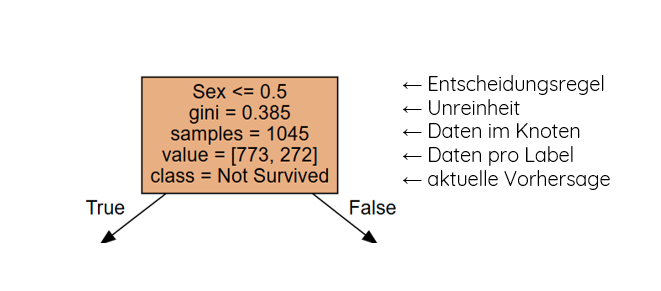

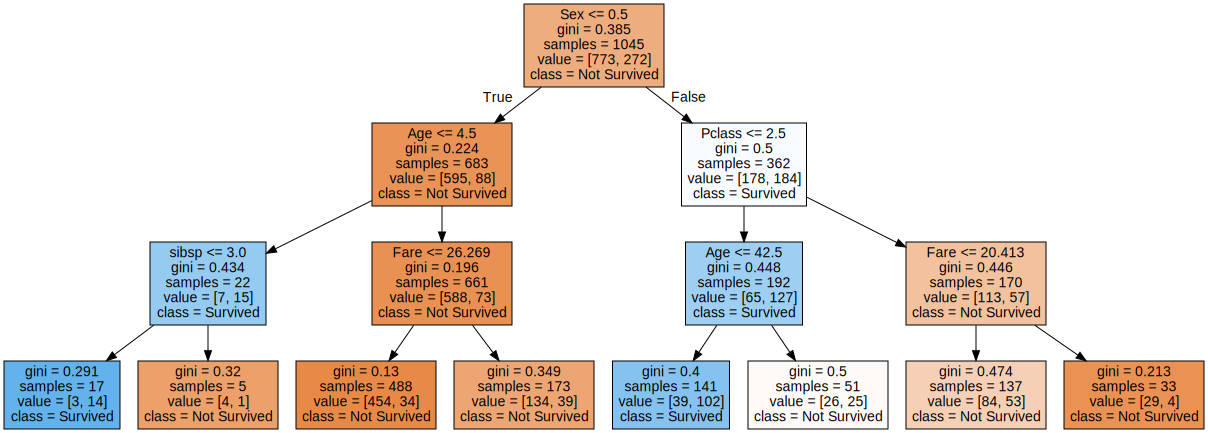

In [ ]:
# Draw graph
graph = graphviz.Source(dot_data, format="png")
graph

Als Grafik mit dtreeviz

In [ ]:
viz_model = dtreeviz.model(model, data, target, target_name="target", class_names=display_labels_, feature_names=data.columns)

In [ ]:
target.dtype

dtype('int64')

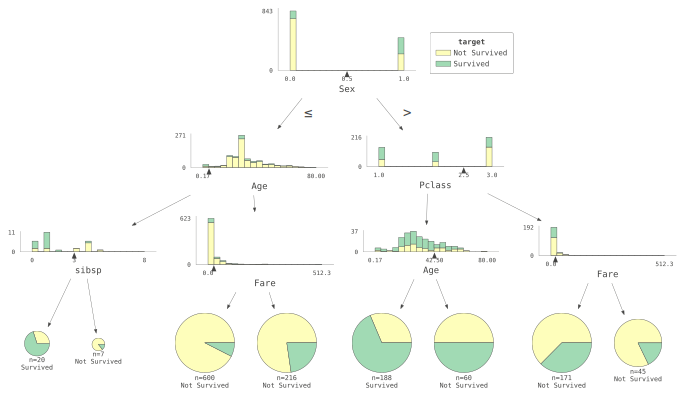

In [ ]:
viz_model.view(scale=1.0, fontname='Monospace')

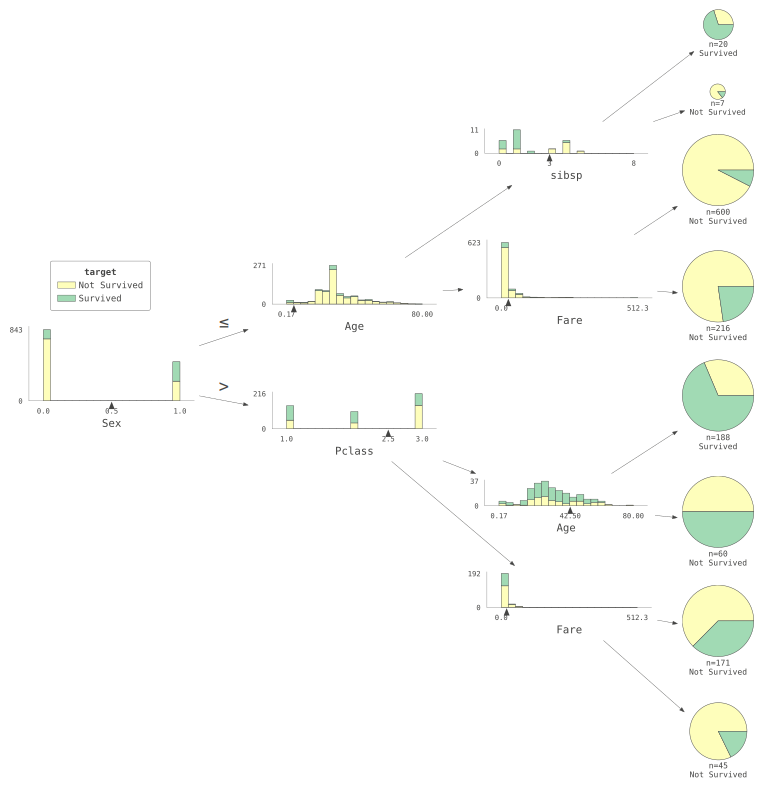

In [ ]:
viz_model.view(scale=1.2, orientation="LR", fontname='Monospace')

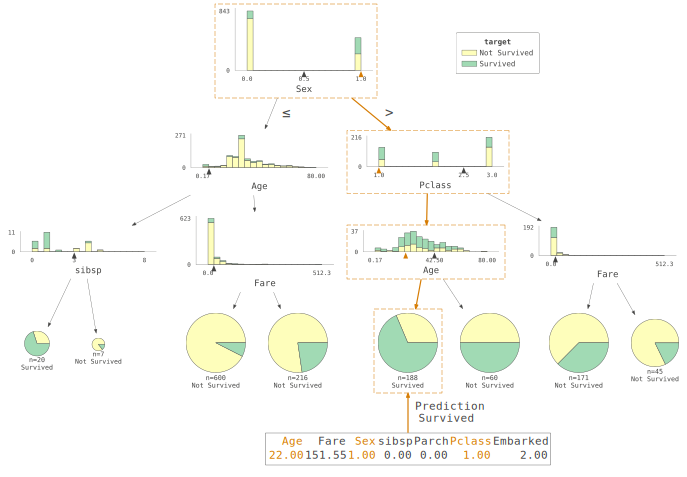

In [ ]:
# local Explanation
one = data_test.iloc[13]
viz_model.view(x=one, fontname='Monospace')

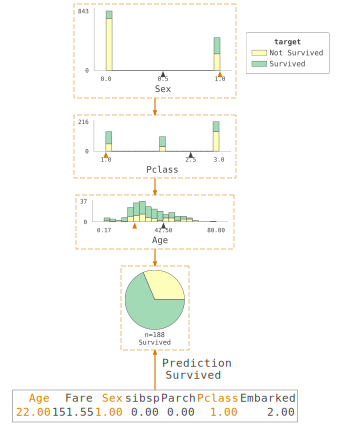

In [ ]:
# local Explanation
viz_model.view(x=one, show_just_path=True, fontname='Monospace')

In [ ]:
tree_img = viz_model.view(scale=0.8, fontname='Monospace')
tree_img.save('tree.svg')

<p><font color='black' size="5">
✔️  Validation Curve
</font></p>

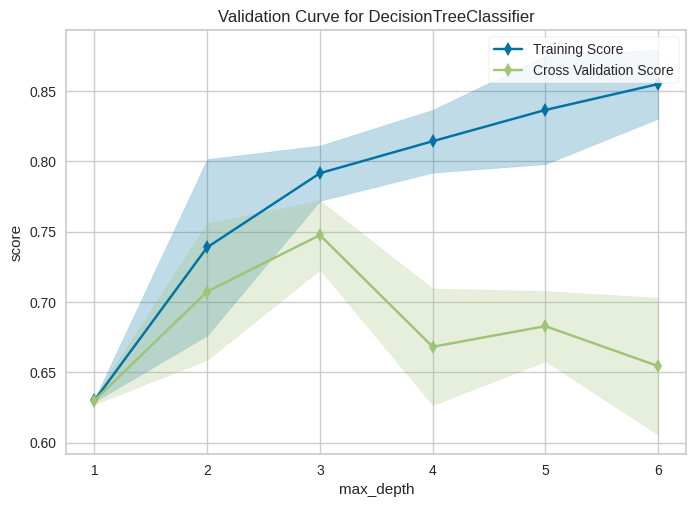

In [ ]:
viz = validation_curve(model, data_test, target_test, param_name="max_depth", param_range=range(1, 7), cv=4, scoring="f1_weighted")

<p><font color='black' size="5">
🎓 Learning Curve
</font></p>

In [ ]:
# Grafik wird zwar erzeugt, jedoch mit vielen Fehlermeldungen 'ValueError'
# learning_curve(model, data, target, cv=4, scoring='accuracy')
#  Clustering: scoring='adjusted_rand_score', Classification: scoring='f1_weighted' oder 'accuracy', Regression: scoring='r2'

In [ ]:
#@title
#@markdown   <p><font size="4" color='green'>  Benutzerfunktion learning curve</font> </br></p>
def plot_learning_curve(model, data, target, cv=2, scoring='accuracy'):
    # Erstellt mit perplexity.ai
    # 24.01.2024
    import plotly.express as px
    import pandas as pd
    from sklearn.model_selection import learning_curve
    import numpy as np
    import plotly.graph_objects as go
    # Berechnen Sie die Lernkurve
    train_sizes, train_scores, test_scores = learning_curve(model, data, target, cv=cv, scoring=scoring)

    # Erstellen Sie ein DataFrame für Plotly
    df = pd.DataFrame({
        'Train Size': train_sizes,
        'Train Score Mean': np.mean(train_scores, axis=1),
        'Train Score Std': np.std(train_scores, axis=1),
        'Test Score Mean': np.mean(test_scores, axis=1),
        'Test Score Std': np.std(test_scores, axis=1)
    })

    # Erstellen Sie das Liniendiagramm für die Trainings- und Test-Scores
    fig = px.line(df, x='Train Size', y='Train Score Mean', error_y='Train Score Std', labels={'Train Score Mean':'Train Score'}, title='Lernkurve - Training')

    # Erstellen Sie ein Scatter-Objekt für die Test-Scores mit Fehlerbalken
    test_score_trace = go.Scatter(
        x=df['Train Size'],
        y=df['Test Score Mean'],
        error_y=dict(
            type='data',
            array=df['Test Score Std'],
            visible=True
        ),
        mode='lines',
        name='Test Score'
    )

    # Fügen Sie das Scatter-Objekt zur Figur hinzu
    fig.add_trace(test_score_trace)

    return fig

In [ ]:
cv = 4
score = 'accuracy'
plot_learning_curve(model, data, target, cv, score)

# **5 <font color='orange'>|</font> Deploy**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>